# Breast Cancer Wisconsin (Рак груди): 
Классическая задача бинарной классификации. Нужно определить, является ли опухоль доброкачественной или злокачественной, на основе 30 числовых признаков, полученных из изображения клеток. Отличный пример для медицинской диагностики.

Попробуем обучить модели KNN, LogisticClassifaer, RandomForest, Adaboost, чтобы выявить, какая из модель лучше подходит для задачи. Также благодаря Adaboost выявим, какие признаки больше важны для модели.

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Загрузка датасета
data = load_breast_cancer()

# создаем датасет с признаками
df = pd.DataFrame(data.data, columns=data.feature_names)

# добавляем таргет в датасет с признаками
df['target'] = data.target

# чтобы показать все колонки
pd.set_option('display.max_columns', None)
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Значение 0 - злокачественная, 1 - доброкачественная.

# 1) Ознакомимся с данными, есть ли пропуски, сбалансированы ли классы? 

## Просмотрим наличие пропусков в данных.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [3]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

### В данных нет пропусков и все данные числовые, нет категориальных

# Посмотрим на то, сбалансированы классы или нет

In [4]:
sns.countplot(data = df, x='target', hue='target')

NameError: name 'sns' is not defined

### Данные сбалансированы

## 2) План

Мы обучим и сравним пять моделей:

| № | Модель                | Класс в `sklearn`            |
|---|-----------------------|------------------------------|
| 1 | KNN                   | `KNeighborsClassifier`       |
| 2 | Логистическая регрессия | `LogisticRegression`       |
| 3 | Решающее дерево       | `DecisionTreeClassifier`     |
| 4 | Случайный лес         | `RandomForestClassifier`     |
| 5 | AdaBoost              | `AdaBoostClassifier`         |

# KNN
Для KNN обязательно нужно нормализовать данные, потому что эта модель работает за счет расстояния признаков.

С помощью поиска по сетке можно будет найти лучшие гиперпараметры

In [6]:
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
RANDOM_STATE = 101

In [8]:
X = df.drop('target', axis=1)
y = df['target']
X.shape

(569, 30)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
#scaler = StandardScaler()

#X_scaler_train = scaler.fit_transform(X_train)
#X_scaler_test  = scaler.transform(X_test)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

param_grid = {
    'knn__n_neighbors': list(range(1, 25)), 
    'knn__weights' : ['uniform', 'distance'],
    "knn__p": [1, 2], 
}     # манхэттенское и евклидово расстояние

full_model = GridSearchCV(pipe, param_grid, scoring='accuracy')

In [29]:
full_model.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [1, 2, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [30]:
full_model.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('knn', KNeighborsClassifier(p=1))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(p=1),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 5,
 'knn__p': 1,
 'knn__weights': 'uniform'}

In [31]:
full_model.cv_results_['mean_test_score']

array([0.96231013, 0.96231013, 0.95727848, 0.95727848, 0.95984177,
       0.96231013, 0.95227848, 0.95727848, 0.96737342, 0.96737342,
       0.96490506, 0.96490506, 0.96737342, 0.96737342, 0.96737342,
       0.96484177, 0.97243671, 0.97243671, 0.96990506, 0.96990506,
       0.96990506, 0.96990506, 0.96740506, 0.96740506, 0.96990506,
       0.96990506, 0.97243671, 0.97243671, 0.97243671, 0.97243671,
       0.96990506, 0.96990506, 0.96237342, 0.96237342, 0.96484177,
       0.96484177, 0.96234177, 0.96234177, 0.96487342, 0.96987342,
       0.95984177, 0.95984177, 0.96990506, 0.96990506, 0.96990506,
       0.96737342, 0.96990506, 0.97240506, 0.95984177, 0.95984177,
       0.97240506, 0.97240506, 0.96237342, 0.95984177, 0.96737342,
       0.96987342, 0.95987342, 0.95987342, 0.96237342, 0.96487342,
       0.96237342, 0.96237342, 0.96237342, 0.96487342, 0.95987342,
       0.95987342, 0.95734177, 0.96487342, 0.95987342, 0.95987342,
       0.95987342, 0.96237342, 0.95987342, 0.95987342, 0.95737

In [32]:
full_model.best_params_['knn__n_neighbors']

5

### Узнаем результат лучшей модели

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, RocCurveDisplay, PredictionErrorDisplay 

In [34]:
y_pred_1 = full_model.predict(X_test)

In [35]:
confusion_matrix(y_test, y_pred_1)

array([[ 58,   8],
       [  3, 102]])

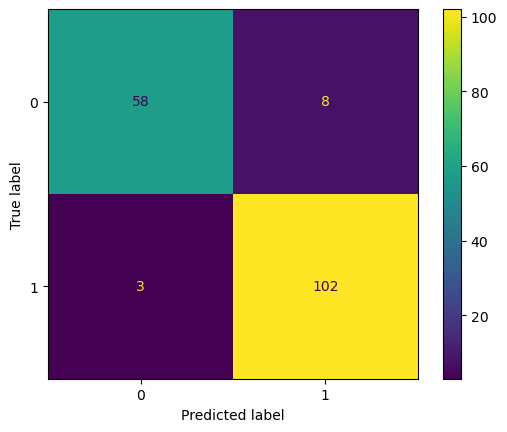

In [36]:
ConfusionMatrixDisplay.from_estimator(full_model, X_test,y_test)

In [38]:
print(classification_report(y_test,y_pred_1))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91        66
           1       0.93      0.97      0.95       105

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



# LogisticRegression

In [39]:
from sklearn.linear_model import LogisticRegression

In [65]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('log', LogisticRegression()),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)


param_grid = {
    'log__solver': ['saga'],
    'log__penalty': ['l1', 'l2', 'elasticnet'],
    'log__l1_ratio': [0.1, 0.5, 0.9],   # используется только при elasticnet
    'log__C': [0.01, 0.1, 1, 10],
    'log__max_iter': [5000],
    'log__class_weight': ['balanced'],
    'log__random_state': [101],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

full_model_logistic = GridSearchCV(estimator=pipe, cv=cv, param_grid=param_grid, scoring='accuracy')

In [66]:
full_model_logistic.fit(X_train, y_train)

C:\Users\roman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\roman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\roman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\roman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\roman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\roman\anaconda3\Lib\site-packag

,estimator,Pipeline(step...egression())])
,param_grid,"{'log__C': [0.01, 0.1, ...], 'log__class_weight': ['balanced'], 'log__l1_ratio': [0.1, 0.5, ...], 'log__max_iter': [5000], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [61]:
full_model_logistic.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('log',
   LogisticRegression(C=1, class_weight='balanced', l1_ratio=0.1, max_iter=5000,
                      random_state=101, solver='saga'))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'log': LogisticRegression(C=1, class_weight='balanced', l1_ratio=0.1, max_iter=5000,
                    random_state=101, solver='saga'),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'log__C': 1,
 'log__class_weight': 'balanced',
 'log__dual': False,
 'log__fit_intercept': True,
 'log__intercept_scaling': 1,
 'log__l1_ratio': 0.1,
 'log__max_iter': 5000,
 'log__multi_class': 'deprecated',
 'log__n_jobs': None,
 'log__penalty': 'l2',
 'log__random_state': 101,
 'log__solver': 'saga',
 'log__tol': 0.0001,
 'log__verbose': 0,
 'log__warm_start': False}

In [62]:
y_pred_log = full_model_logistic.predict(X_test)
confusion_matrix(y_test, y_pred_log)

array([[ 63,   3],
       [  2, 103]])

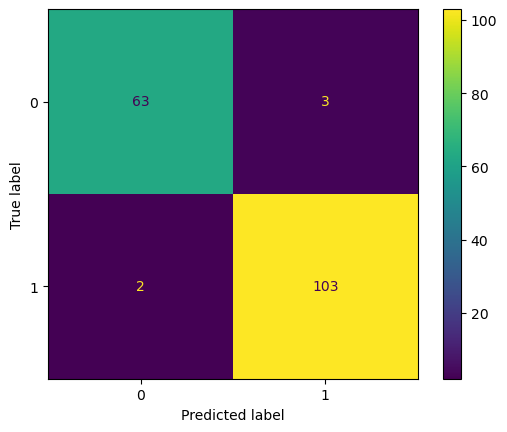

In [63]:
ConfusionMatrixDisplay.from_estimator(full_model_logistic, X_test,y_test)

In [64]:
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        66
           1       0.97      0.98      0.98       105

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



# DecisionTreeClassifier and RandomForest

In [67]:
from sklearn.tree import DecisionTreeClassifier

In [79]:
pipe = Pipeline([
    ('decision', DecisionTreeClassifier()),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

param_grid = {
    'decision__random_state': [101],
    'decision__class_weight': ['balanced']
}
full_model_decision = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=cv, scoring='accuracy')

In [80]:
full_model_decision.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'decision__class_weight': ['balanced'], 'decision__random_state': [101]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [81]:
y_pred_decision = full_model_decision.predict(X_test)
confusion_matrix(y_test, y_pred_decision)

array([[62,  4],
       [ 8, 97]])

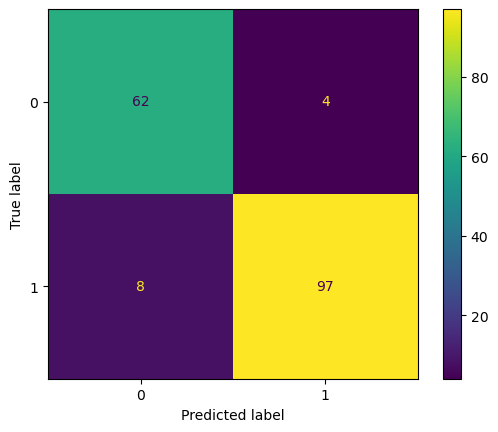

In [83]:
ConfusionMatrixDisplay.from_estimator(full_model_decision, X_test,y_test)

In [84]:
print(classification_report(y_test,y_pred_decision))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91        66
           1       0.96      0.92      0.94       105

    accuracy                           0.93       171
   macro avg       0.92      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171



# AdaBoostClassifier

In [88]:
from sklearn.ensemble import AdaBoostClassifier
import numpy as np

In [98]:
ad = AdaBoostClassifier()

param_grid = {
    'n_estimators':  [10, 25, 50, 75, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator':     [DecisionTreeClassifier(max_depth=1)],
    'random_state':  [101],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

finall_model_ad = GridSearchCV(
    ad, param_grid, cv=cv, scoring='accuracy', n_jobs=-1
)

finall_model_ad.fit(X_train, y_train)
print(finall_model_ad.best_params_, finall_model_ad.best_score_)

{'estimator': DecisionTreeClassifier(max_depth=1), 'learning_rate': 1.0, 'n_estimators': 100, 'random_state': 101} 0.9874367088607595


In [100]:
finall_model_ad.fit(X_train, y_train)


,estimator,AdaBoostClassifier()
,param_grid,"{'estimator': [DecisionTreeC...r(max_depth=1)], 'learning_rate': [0.01, 0.1, ...], 'n_estimators': [10, 25, ...], 'random_state': [101]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [101]:
y_pred_ad = finall_model_ad.predict(X_test)
confusion_matrix(y_test, y_pred_ad)

array([[ 62,   4],
       [  2, 103]])

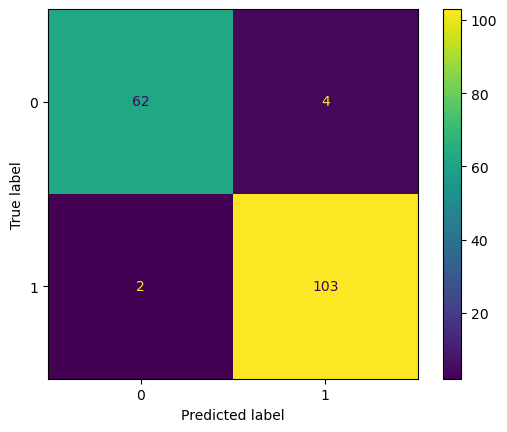

In [102]:
ConfusionMatrixDisplay.from_estimator(finall_model_ad, X_test,y_test)

In [103]:
print(classification_report(y_test,y_pred_ad))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95        66
           1       0.96      0.98      0.97       105

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



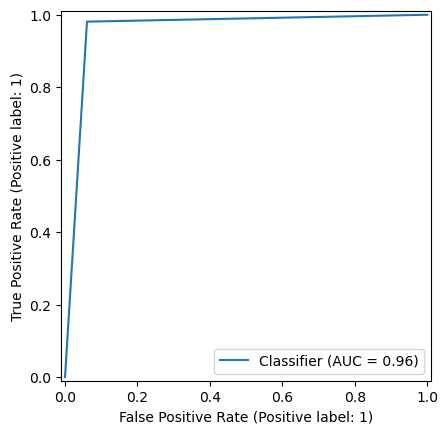

In [107]:
RocCurveDisplay.from_predictions(y_test, y_pred_ad)

In [111]:
from sklearn.metrics import accuracy_score, PrecisionRecallDisplay

In [112]:
from tqdm import tqdm

error_rates = []

for n in tqdm(range(1, 96)):
    model = AdaBoostClassifier(n_estimators=n)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    error = 1 - accuracy_score(y_test, preds)
    error_rates.append(error)

100%|██████████████████████████████████████████████████████████████████████████████████| 95/95 [00:12<00:00,  7.73it/s]


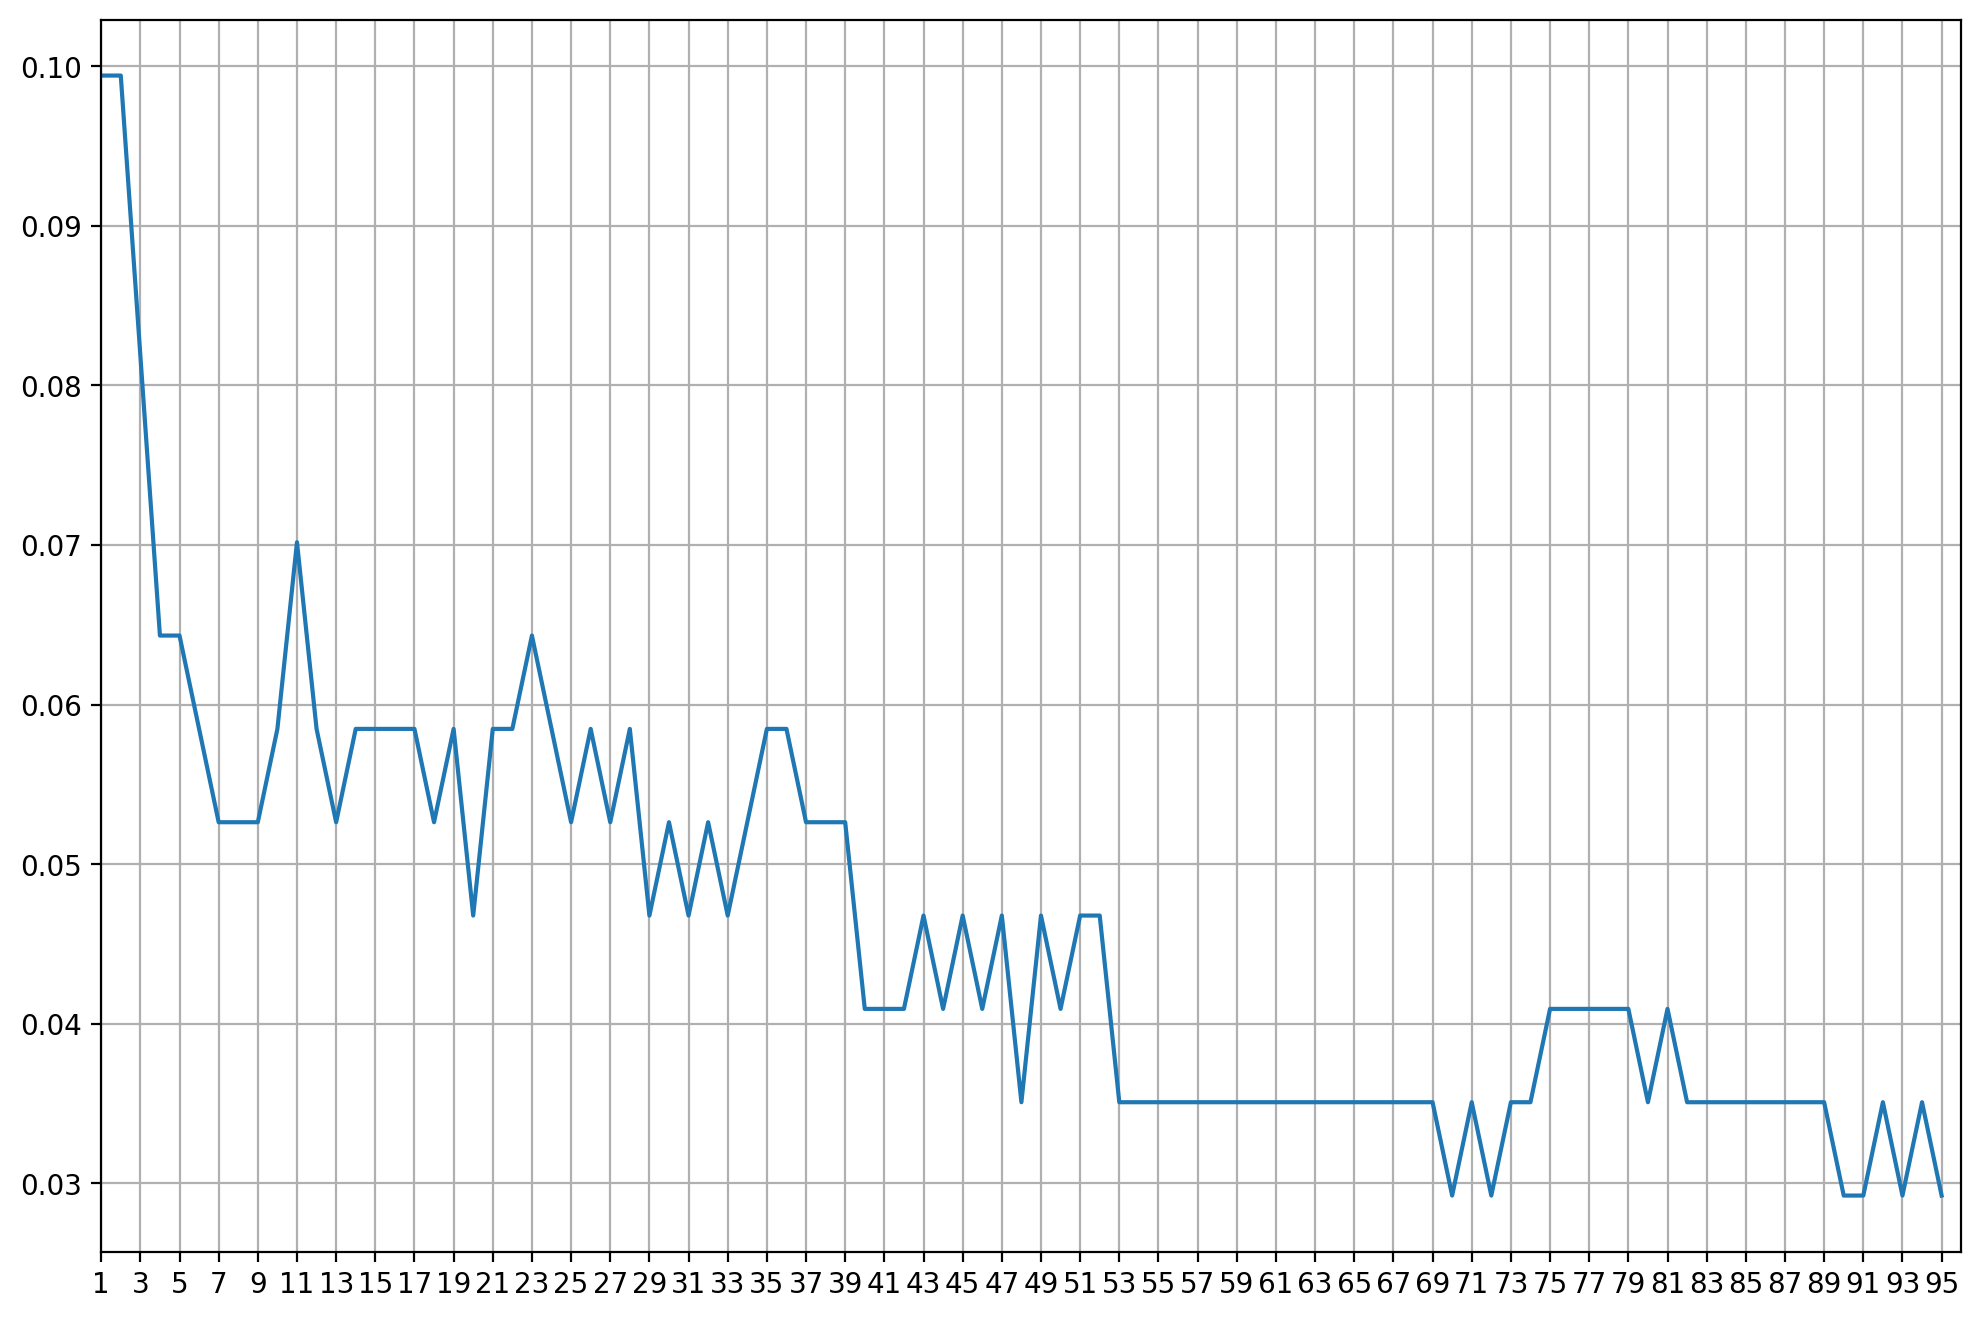

In [113]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

ax.plot(range(1, 96), error_rates)
ax.set_xlim(1, 96)
ax.set_xticks(range(1, 96, 2))
ax.grid()

# посмотрим, какие признаки adaboost считает лучшими

In [116]:
feats = pd.DataFrame(index=X.columns, data=model.feature_importances_, columns=['Важность'])
imp_feat = feats[feats['Важность'] > 0]
imp_feat.sort_values('Важность', ascending=False, inplace=True)

C:\Users\roman\AppData\Local\Temp\ipykernel_28196\3140033332.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imp_feat.sort_values('Важность', ascending=False, inplace=True)


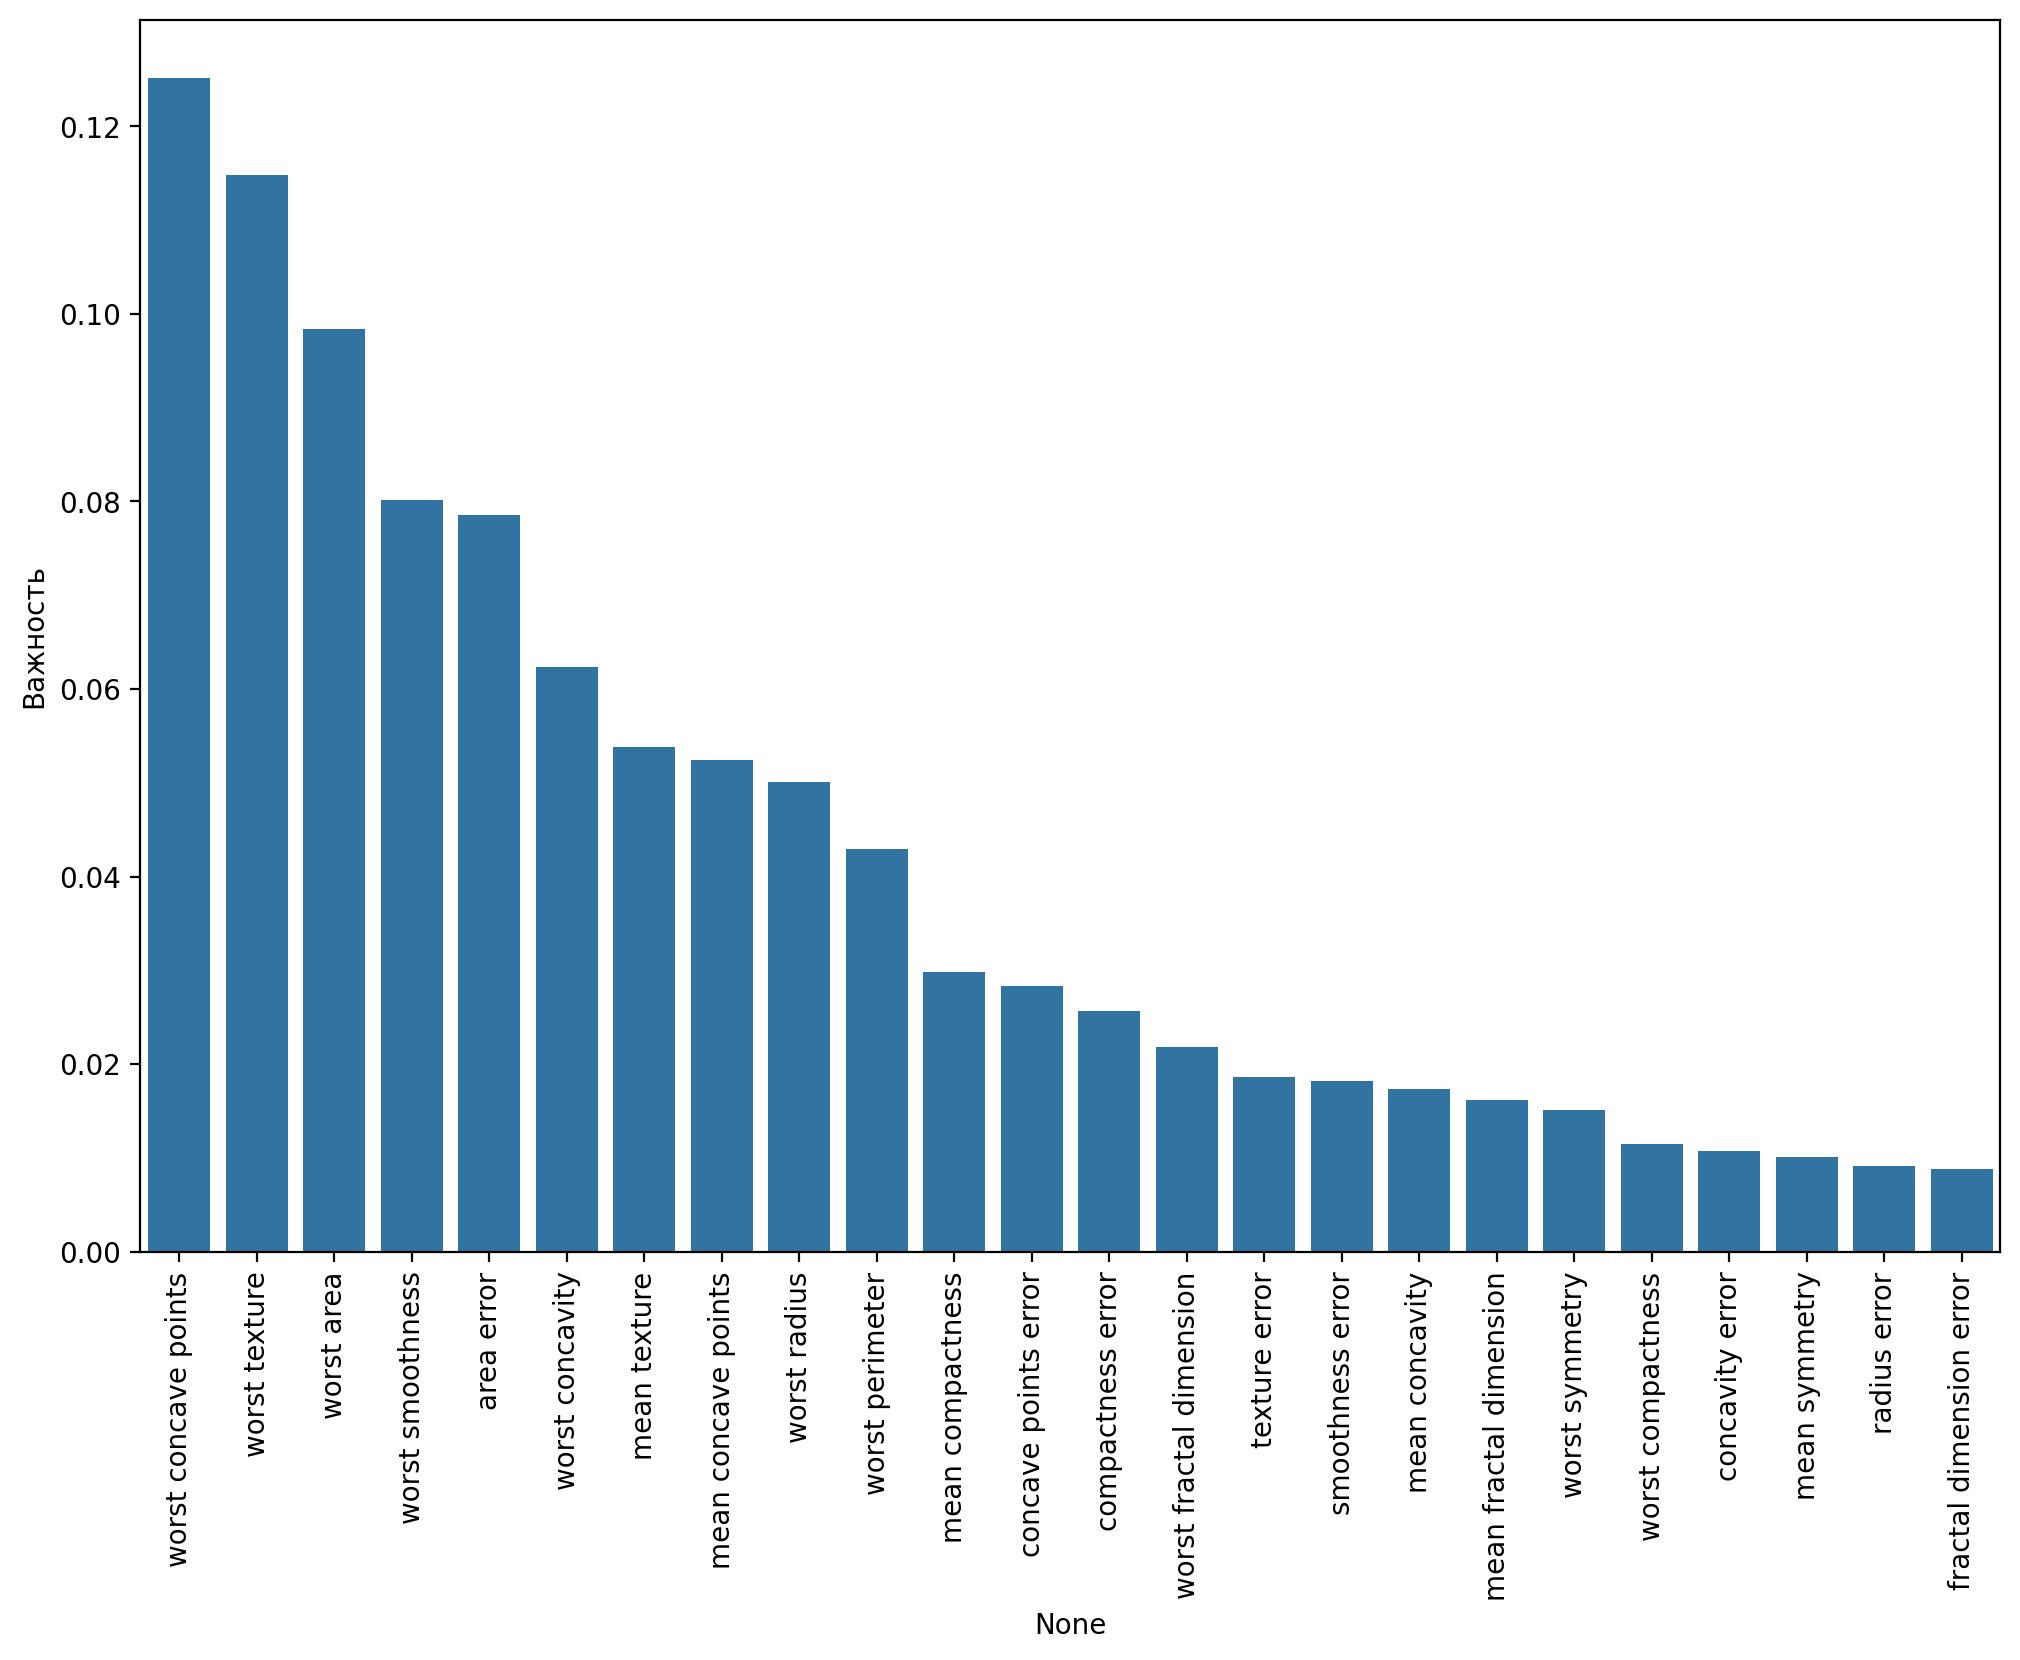

In [117]:

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
sns.barplot(data=imp_feat, x=imp_feat.index, y='Важность', ax=ax)
plt.xticks(ticks=imp_feat.index,rotation=90);

### Именно такие признаки имеют большую роль по мнению adaboost